# CSE425 — Multi-Genre Music Generation
## Steps 5 & 6 — Task 1: LSTM Autoencoder  |  Task 2: Variational Autoencoder




## Cell 0 — Fresh Session Recovery

In [2]:
import os
PROCESSED_DIR = '/content/processed'
DATA_DIR      = '/content/maestro'

if not os.path.exists(os.path.join(PROCESSED_DIR, 'piano_roll_train.npy')):
    print('Processed files not found — rebuilding...')
    MAESTRO_URL = 'https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip'
    if not os.path.exists(os.path.join(DATA_DIR, 'maestro-v3.0.0.csv')):
        !wget -q --show-progress -O /content/maestro.zip {MAESTRO_URL}
        !unzip -q /content/maestro.zip -d /content/
        !mv /content/maestro-v3.0.0 {DATA_DIR} 2>/dev/null || true
    !pip install pretty_midi --quiet
    import numpy as np, pandas as pd, pretty_midi
    from tqdm.auto import tqdm
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    FS, WL, PL, PH = 16, 128, 21, 109
    NP = PH - PL
    def midi_to_wins(fp):
        try:
            pm = pretty_midi.PrettyMIDI(fp)
            r  = pm.get_piano_roll(fs=FS)[PL:PH,:].T
            r  = (r > 0).astype(np.uint8)
            n  = r.shape[0] // WL
            if n == 0: return None
            w  = r[:n*WL].reshape(n, WL, NP)
            w  = w[w.mean(axis=(1,2)) >= 0.02]
            return w if len(w) > 0 else None
        except: return None
    meta = pd.read_csv(os.path.join(DATA_DIR,'maestro-v3.0.0.csv'))
    meta['filepath'] = meta['midi_filename'].apply(lambda p: os.path.join(DATA_DIR,p))
    MAX_FILES = 60
    for split in ['train','validation','test']:
        df = meta[meta['split']==split]
        if MAX_FILES: df = df.head(MAX_FILES if split=='train' else max(8,MAX_FILES//8))
        bufs = [w for fp in tqdm(df['filepath'],desc=split) if (w:=midi_to_wins(fp)) is not None]
        arr  = np.concatenate(bufs,axis=0) if bufs else np.empty((0,WL,NP),dtype=np.uint8)
        np.save(os.path.join(PROCESSED_DIR,f'piano_roll_{split}.npy'),arr)
        print(f'{split}: {arr.shape}')
    print('Rebuild complete.')
else:
    print('Processed files found — skipping rebuild.')

Processed files not found — rebuilding...


train:   0%|          | 0/60 [00:00<?, ?it/s]

train: (3772, 128, 88)


validation:   0%|          | 0/8 [00:00<?, ?it/s]

validation: (421, 128, 88)


test:   0%|          | 0/8 [00:00<?, ?it/s]

test: (413, 128, 88)
Rebuild complete.



## Cell 1 — Install & Imports

In [3]:
!pip install pretty_midi --quiet

import os, time, random, json
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pretty_midi
from tqdm.auto import tqdm
import pandas as pd

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)

Device : cuda
GPU    : Tesla T4



## Cell 2 — Global Configuration
All hyper-parameters in one place.

In [4]:
#  Paths
DATA_DIR      = '/content/maestro'
PROCESSED_DIR = '/content/processed'
OUT_TASK1     = '/content/task1_outputs'
OUT_TASK2     = '/content/task2_outputs'
for d in [OUT_TASK1, OUT_TASK2,
          os.path.join(OUT_TASK1,'generated_midi'),
          os.path.join(OUT_TASK2,'generated_midi'),
          os.path.join(OUT_TASK2,'interpolations')]:
    os.makedirs(d, exist_ok=True)

# Piano-roll dims
WINDOW_LEN  = 128
N_PITCHES   = 88
FS          = 16
PIANO_LOW   = 21

# Shared model architecture
HIDDEN_DIM  = 256
LATENT_DIM  = 64
NUM_LAYERS  = 2
DROPOUT     = 0.2

#Training
BATCH_SIZE  = 64
NUM_WORKERS = 2
LR          = 1e-3
GRAD_CLIP   = 1.0

#  Epochs per task
EPOCHS_TASK1 = 30
EPOCHS_TASK2 = 30

# Focal Loss
FOCAL_POS_WEIGHT = 30.0
FOCAL_GAMMA      = 2.0

# VAE-specific
KL_WARMUP_EPOCHS = 20
KL_BETA_MAX      = 1.0

#  Generation
GEN_THRESHOLD = 0.30
N_GEN_TASK1   = 5
N_GEN_TASK2   = 8
N_INTERP      = 8

print('Configuration loaded.')
print(f'  Architecture : {NUM_LAYERS}-layer LSTM  hidden={HIDDEN_DIM}  latent={LATENT_DIM}')
print(f'  Task 1       : {EPOCHS_TASK1} epochs')
print(f'  Task 2       : {EPOCHS_TASK2} epochs  KL warmup={KL_WARMUP_EPOCHS}')

Configuration loaded.
  Architecture : 2-layer LSTM  hidden=256  latent=64
  Task 1       : 30 epochs
  Task 2       : 30 epochs  KL warmup=20



## Cell 3 — Dataset & DataLoaders (shared by both tasks)

In [5]:
class PianoRollDataset(Dataset):
    """Wraps a (N,128,88) uint8 array. Returns float32 tensors of shape (128,88)."""
    def __init__(self, npy_path):
        arr = np.load(npy_path)
        self.data = torch.from_numpy(arr.astype(np.float32))
        print(f'  {os.path.basename(npy_path):40s} → {tuple(self.data.shape)}')
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

print('Loading datasets...')
ds_train = PianoRollDataset(os.path.join(PROCESSED_DIR,'piano_roll_train.npy'))
ds_val   = PianoRollDataset(os.path.join(PROCESSED_DIR,'piano_roll_validation.npy'))
ds_test  = PianoRollDataset(os.path.join(PROCESSED_DIR,'piano_roll_test.npy'))

def make_loaders(ds_tr, ds_v, ds_te, batch_size=BATCH_SIZE):
    kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    return (
        DataLoader(ds_tr, batch_size=batch_size, shuffle=True,  drop_last=True,  **kw),
        DataLoader(ds_v,  batch_size=batch_size, shuffle=False,                  **kw),
        DataLoader(ds_te, batch_size=batch_size, shuffle=False,                  **kw),
    )

loader_train, loader_val, loader_test = make_loaders(ds_train, ds_val, ds_test)

b = next(iter(loader_train))
print(f'\nBatch shape : {b.shape}  dtype={b.dtype}  range=[{b.min():.0f},{b.max():.0f}]')
print(f'Train batches/epoch : {len(loader_train)}')

Loading datasets...
  piano_roll_train.npy                     → (3772, 128, 88)
  piano_roll_validation.npy                → (421, 128, 88)
  piano_roll_test.npy                      → (413, 128, 88)

Batch shape : torch.Size([64, 128, 88])  dtype=torch.float32  range=[0,1]
Train batches/epoch : 58



## Cell 4 — Shared Utilities: Focal Loss, MIDI Export, Metrics

In [6]:

class FocalLoss(nn.Module):
    """
    Binary Focal Loss for sparse piano-roll reconstruction.
    Expects raw logits (NO sigmoid on model output layer).

    L = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=FOCAL_GAMMA, pos_weight=FOCAL_POS_WEIGHT):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # logits, targets : (B, T, 88)
        bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs  = torch.sigmoid(logits)
        p_t    = targets * probs + (1 - targets) * (1 - probs)
        focal  = (1.0 - p_t) ** self.gamma
        alpha  = targets * self.pos_weight + (1 - targets) * 1.0
        return (alpha * focal * bce).mean()

criterion = FocalLoss()

# Smoke test
_l = criterion(torch.randn(2,WINDOW_LEN,N_PITCHES),
               torch.randint(0,2,(2,WINDOW_LEN,N_PITCHES)).float())
print(f'FocalLoss smoke test: {_l.item():.4f}  ✓')


# MIDI EXPORT

def piano_roll_to_midi(binary_roll, fs=FS, piano_low=PIANO_LOW, velocity=80):
    """
    binary_roll : (T, 88) numpy uint8
    Returns a pretty_midi.PrettyMIDI object (program 0 = Acoustic Grand Piano).
    """
    pm   = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0)
    dt   = 1.0 / fs
    T, P = binary_roll.shape
    for p in range(P):
        active = False; start = 0.0
        for t in range(T):
            if binary_roll[t, p] == 1 and not active:
                start = t * dt; active = True
            elif binary_roll[t, p] == 0 and active:
                end = t * dt
                if end - start >= dt:
                    inst.notes.append(pretty_midi.Note(velocity, piano_low + p, start, end))
                active = False
        if active:
            inst.notes.append(pretty_midi.Note(velocity, piano_low + p, start, T * dt))
    pm.instruments.append(inst)
    return pm

def verify_midi(pm, min_notes=50, min_dur=5.0):
    notes = sum(len(i.notes) for i in pm.instruments)
    return notes >= min_notes and pm.get_end_time() >= min_dur


# EVALUATION METRICS

def pitch_histogram_similarity(pm_gen, pm_ref):
    """L1 distance between 12-class pitch distributions. Lower = better. Max=2."""
    def dist(pm):
        c = np.zeros(12)
        for inst in pm.instruments:
            for n in inst.notes: c[n.pitch % 12] += 1
        s = c.sum()
        return c / s if s > 0 else c
    return float(np.abs(dist(pm_ref) - dist(pm_gen)).sum())

def rhythm_diversity(pm):
    """Unique quantized durations / total notes. Higher = more rhythmic variety."""
    durs = [round((n.end-n.start)/0.05)*0.05
            for inst in pm.instruments for n in inst.notes]
    return len(set(durs)) / len(durs) if durs else 0.0

def repetition_ratio(pm, n=4):
    """Repeated 4-grams / total 4-grams. Healthy range: 0.1–0.5."""
    notes = sorted([n for i in pm.instruments for n in i.notes], key=lambda x: x.start)
    pitches = [n.pitch for n in notes]
    if len(pitches) < n: return 0.0
    grams = [tuple(pitches[i:i+n]) for i in range(len(pitches)-n+1)]
    return sum(1 for c in Counter(grams).values() if c > 1) / len(grams)

def compute_metrics(paths, ref_pm):
    """Compute all three metrics and return means."""
    ph_all, rd_all, rr_all = [], [], []
    for p in paths:
        pm = pretty_midi.PrettyMIDI(p)
        ph_all.append(pitch_histogram_similarity(pm, ref_pm))
        rd_all.append(rhythm_diversity(pm))
        rr_all.append(repetition_ratio(pm))
    return np.mean(ph_all), np.mean(rd_all), np.mean(rr_all)

# Load one test-set reference MIDI for pitch histogram comparison
meta = pd.read_csv(os.path.join(DATA_DIR,'maestro-v3.0.0.csv'))
meta['filepath'] = meta['midi_filename'].apply(lambda p: os.path.join(DATA_DIR,p))
REF_PM = pretty_midi.PrettyMIDI(meta[meta['split']=='test']['filepath'].iloc[0])
print('Utilities ready.')

FocalLoss smoke test: 5.3113  ✓
Utilities ready.




# TASK 1 — LSTM AUTOENCODER


## Cell 5 — Encoder

In [21]:
class Encoder(nn.Module):

    def __init__(self, input_dim=N_PITCHES, hidden_dim=HIDDEN_DIM,
                 latent_dim=LATENT_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x      : (B, T, 88)
        # h_n    : (num_layers, B, hidden_dim)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])          # (B, latent_dim)

print('Encoder defined.')

Encoder defined.


## Cell 6 — Decoder

In [22]:
class Decoder(nn.Module):

    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM,
                 output_dim=N_PITCHES, num_layers=NUM_LAYERS,
                 seq_len=WINDOW_LEN, dropout=DROPOUT):
        super().__init__()
        self.seq_len    = seq_len
        self.latent_dim = latent_dim
        self.lstm = nn.LSTM(
            input_size  = latent_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_dim, output_dim)   # raw logits

    def forward(self, z):
        # z : (B, latent_dim)
        B     = z.size(0)
        z_seq = z.unsqueeze(1).expand(B, self.seq_len, self.latent_dim)  # (B,T,latent)
        out, _ = self.lstm(z_seq)                                         # (B,T,hidden)
        return self.fc_out(out)                                           # (B,T,88)

print('Decoder defined.')

Decoder defined.


## Cell 7 — LSTM Autoencoder (Task 1 model)

In [23]:
class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        """x: (B,T,88) → logits (B,T,88)"""
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

    @torch.no_grad()
    def generate(self, n=1, threshold=GEN_THRESHOLD):

        self.eval()
        z      = torch.randn(n, LATENT_DIM, device=DEVICE)
        logits = self.decoder(z)
        probs  = torch.sigmoid(logits)
        return (probs > threshold).cpu().numpy().astype(np.uint8)


ae_model = LSTMAutoencoder().to(DEVICE)
params   = sum(p.numel() for p in ae_model.parameters() if p.requires_grad)
print(f'LSTMAutoencoder  |  parameters: {params:,}')

# Shape check
with torch.no_grad():
    _out = ae_model(torch.zeros(4, WINDOW_LEN, N_PITCHES, device=DEVICE))
assert _out.shape == (4, WINDOW_LEN, N_PITCHES)
print(f'Forward pass shape: {_out.shape}  ✓')

LSTMAutoencoder  |  parameters: 1,775,768
Forward pass shape: torch.Size([4, 128, 88])  ✓


## Cell 8 — Task 1 Training Loop

In [25]:
def run_epoch(model, loader, optimizer=None, criterion=criterion, clip=GRAD_CLIP):
    """One training or validation epoch. Pass optimizer=None for eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total = 0.0
    ctx   = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            x = batch.to(DEVICE, non_blocking=True)
            if training: optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, x)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            total += loss.item()
    return total / len(loader)


CKPT_AE = os.path.join(OUT_TASK1, 'best_lstm_ae.pt')
optim_ae = torch.optim.Adam(ae_model.parameters(), lr=LR)
sched_ae = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_ae, mode='min', factor=0.5, patience=8)

t1_train_losses, t1_val_losses = [], []
best_ae_val = float('inf')
t0 = time.time()

print(f'Training LSTM Autoencoder for {EPOCHS_TASK1} epochs...')
print('─' * 62)

for epoch in range(1, EPOCHS_TASK1 + 1):
    tr_loss = run_epoch(ae_model, loader_train, optimizer=optim_ae)
    vl_loss = run_epoch(ae_model, loader_val)
    t1_train_losses.append(tr_loss)
    t1_val_losses.append(vl_loss)
    sched_ae.step(vl_loss)

    tag = ''
    if vl_loss < best_ae_val:
        best_ae_val = vl_loss
        torch.save({'epoch': epoch, 'model_state': ae_model.state_dict(),
                    'val_loss': best_ae_val}, CKPT_AE)
        tag = ' ← best'

    elapsed = (time.time() - t0) / 60
    print(f'  Epoch {epoch:3d}/{EPOCHS_TASK1}  train={tr_loss:.4f}  '
          f'val={vl_loss:.4f}  [{elapsed:.1f} min]{tag}')

print('─' * 62)
print(f'Task 1 done. Best val loss: {best_ae_val:.4f}')

Training LSTM Autoencoder for 30 epochs...
──────────────────────────────────────────────────────────────
  Epoch   1/30  train=0.4060  val=0.3673  [0.1 min] ← best
  Epoch   2/30  train=0.3944  val=0.3608  [0.1 min] ← best
  Epoch   3/30  train=0.3877  val=0.3582  [0.2 min] ← best
  Epoch   4/30  train=0.3981  val=0.3624  [0.2 min]
  Epoch   5/30  train=0.3920  val=0.3661  [0.3 min]
  Epoch   6/30  train=0.3916  val=0.3566  [0.3 min] ← best
  Epoch   7/30  train=0.3741  val=0.3519  [0.4 min] ← best
  Epoch   8/30  train=0.3713  val=0.3525  [0.4 min]
  Epoch   9/30  train=0.3638  val=0.3451  [0.5 min] ← best
  Epoch  10/30  train=0.3590  val=0.3420  [0.5 min] ← best
  Epoch  11/30  train=0.3553  val=0.3404  [0.6 min] ← best
  Epoch  12/30  train=0.3504  val=0.3387  [0.6 min] ← best
  Epoch  13/30  train=0.3470  val=0.3384  [0.7 min] ← best
  Epoch  14/30  train=0.3436  val=0.3388  [0.7 min]
  Epoch  15/30  train=0.3402  val=0.3315  [0.8 min] ← best
  Epoch  16/30  train=0.3317  val=0.3

## Cell 9 — Task 1 Loss Curve

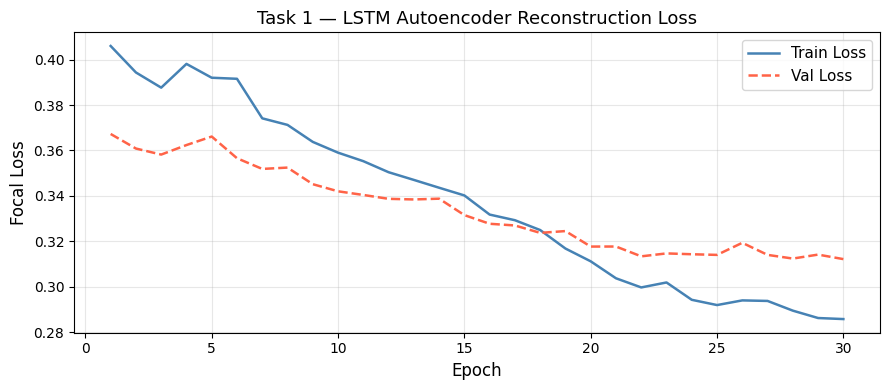

Saved → /content/task1_outputs/task1_loss_curve.png
Final train=0.2857  val=0.3121  best_val=0.3121

Interpreting the curve:
  GOOD  : Both lines decrease then plateau. Val follows train closely.
  BAD   : Plateau from epoch 1 → check pos_weight / focal loss.
  BAD   : Val rises while train falls → overfitting; raise DROPOUT.


In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs  = range(1, len(t1_train_losses) + 1)
ax.plot(epochs, t1_train_losses, '-',  color='steelblue', lw=1.8, label='Train Loss')
ax.plot(epochs, t1_val_losses,   '--', color='tomato',    lw=1.8, label='Val Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Focal Loss', fontsize=12)
ax.set_title('Task 1 — LSTM Autoencoder Reconstruction Loss', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(OUT_TASK1, 'task1_loss_curve.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved → {plot_path}')
print(f'Final train={t1_train_losses[-1]:.4f}  val={t1_val_losses[-1]:.4f}  best_val={best_ae_val:.4f}')
print()
print('Interpreting the curve:')
print('  GOOD  : Both lines decrease then plateau. Val follows train closely.')
print('  BAD   : Plateau from epoch 1 → check pos_weight / focal loss.')
print('  BAD   : Val rises while train falls → overfitting; raise DROPOUT.')

## Cell 10 — Task 1 Generate 5 MIDI Samples

In [28]:
# Load best weights before generating
ckpt = torch.load(CKPT_AE, map_location=DEVICE)
ae_model.load_state_dict(ckpt['model_state'])
print(f'Loaded best AE checkpoint (epoch {ckpt["epoch"]}, val={ckpt["val_loss"]:.4f})')

midi_dir_t1  = os.path.join(OUT_TASK1, 'generated_midi')
gen_paths_t1 = []
attempts = 0
threshold = GEN_THRESHOLD

print(f'\nGenerating {N_GEN_TASK1} MIDI samples (threshold={threshold})...')

while len(gen_paths_t1) < N_GEN_TASK1 and attempts < N_GEN_TASK1 * 6:
    attempts += 1
    roll = ae_model.generate(n=1, threshold=threshold)[0]  # (T,88)
    pm   = piano_roll_to_midi(roll)
    if not verify_midi(pm):
        # Progressively lower threshold if generation produces too few notes
        threshold = max(0.10, threshold - 0.02)
        print(f'  Attempt {attempts}: rejected — lowering threshold to {threshold:.2f}')
        continue
    idx  = len(gen_paths_t1) + 1
    path = os.path.join(midi_dir_t1, f'task1_gen_{idx:02d}.mid')
    pm.write(path)
    gen_paths_t1.append(path)
    n_notes = sum(len(i.notes) for i in pm.instruments)
    print(f'  Sample {idx}: {n_notes} notes  dur={pm.get_end_time():.1f}s  → {path}')

print(f'\n✓  Generated {len(gen_paths_t1)}/{N_GEN_TASK1} MIDI files.')

Loaded best AE checkpoint (epoch 30, val=0.3121)

Generating 5 MIDI samples (threshold=0.3)...
  Sample 1: 78 notes  dur=8.0s  → /content/task1_outputs/generated_midi/task1_gen_01.mid
  Sample 2: 74 notes  dur=8.0s  → /content/task1_outputs/generated_midi/task1_gen_02.mid
  Sample 3: 86 notes  dur=8.0s  → /content/task1_outputs/generated_midi/task1_gen_03.mid
  Sample 4: 67 notes  dur=8.0s  → /content/task1_outputs/generated_midi/task1_gen_04.mid
  Sample 5: 79 notes  dur=8.0s  → /content/task1_outputs/generated_midi/task1_gen_05.mid

✓  Generated 5/5 MIDI files.


## Cell 11 — Task 1 Metrics & Reconstruction Check

Task 1 Metrics:
  Reconstruction Loss (val)  : 0.3121
  Test Loss                  : 0.3029
  Pitch Histogram Similarity : 0.342  (lower=better, max=2)
  Rhythm Diversity           : 0.060  (higher=more variety)
  Repetition Ratio           : 0.000  (healthy: 0.1–0.5)


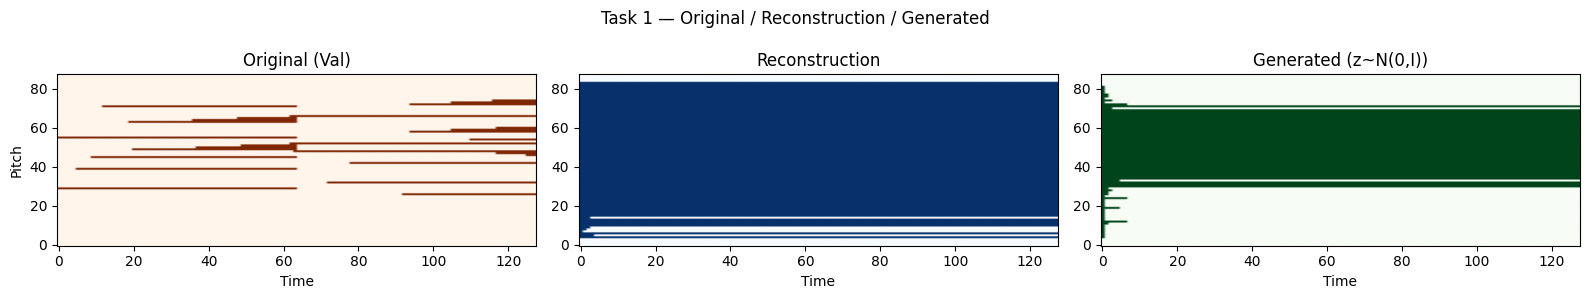


Note recall : 100.0%


In [29]:
#  Metrics
t1_ph, t1_rd, t1_rr = compute_metrics(gen_paths_t1, REF_PM)
t1_test_loss = run_epoch(ae_model, loader_test)

print('Task 1 Metrics:')
print(f'  Reconstruction Loss (val)  : {best_ae_val:.4f}')
print(f'  Test Loss                  : {t1_test_loss:.4f}')
print(f'  Pitch Histogram Similarity : {t1_ph:.3f}  (lower=better, max=2)')
print(f'  Rhythm Diversity           : {t1_rd:.3f}  (higher=more variety)')
print(f'  Repetition Ratio           : {t1_rr:.3f}  (healthy: 0.1–0.5)')

#Reconstruction visual
ae_model.eval()
with torch.no_grad():
    real   = ds_val[10].unsqueeze(0).to(DEVICE)
    logits = ae_model(real)
    recon  = (torch.sigmoid(logits) > GEN_THRESHOLD).float()

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
axes[0].imshow(ds_val[10].numpy().T,   aspect='auto', origin='lower', cmap='Oranges')
axes[0].set_title('Original (Val)'); axes[0].set_xlabel('Time'); axes[0].set_ylabel('Pitch')
axes[1].imshow(recon.squeeze(0).cpu().numpy().T, aspect='auto', origin='lower', cmap='Blues')
axes[1].set_title('Reconstruction'); axes[1].set_xlabel('Time')
roll_gen = ae_model.generate(n=1, threshold=GEN_THRESHOLD)[0]
axes[2].imshow(roll_gen.T, aspect='auto', origin='lower', cmap='Greens')
axes[2].set_title('Generated (z~N(0,I))'); axes[2].set_xlabel('Time')
plt.suptitle('Task 1 — Original / Reconstruction / Generated', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_TASK1, 'task1_comparison.png'), dpi=150)
plt.show()

# Note recall (of real active notes, how many were recovered?)
real_np  = ds_val[10].numpy()
recon_np = recon.squeeze(0).cpu().numpy()
if real_np.sum() > 0:
    recall = recon_np[real_np == 1].mean() * 100
    print(f'\nNote recall : {recall:.1f}%')


# TASK 2 — VARIATIONAL AUTOENCODER (VAE)



## Cell 12 — VAE Encoder (outputs μ and log σ²)

In [30]:
class VAEEncoder(nn.Module):

    def __init__(self, input_dim=N_PITCHES, hidden_dim=HIDDEN_DIM,
                 latent_dim=LATENT_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        # Separate heads for mean and log-variance
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x : (B, T, 88)
        _, (h_n, _) = self.lstm(x)   # h_n: (num_layers, B, hidden_dim)
        h           = h_n[-1]         # (B, hidden_dim)
        mu          = self.fc_mu(h)           # (B, latent_dim)
        log_var     = self.fc_log_var(h)      # (B, latent_dim)
        return mu, log_var

print('VAEEncoder defined.')

VAEEncoder defined.


## Cell 13 — VAE Model (Encoder + Reparameterization + Decoder)

In [31]:
class VAE(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = VAEEncoder()
        self.decoder = Decoder()     # same Decoder class as Task 1

    def reparameterize(self, mu, log_var):

        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def forward(self, x):
        """
        x       : (B, T, 88)
        Returns : (logits (B,T,88), mu (B,latent), log_var (B,latent))
        """
        mu, log_var = self.encoder(x)
        z           = self.reparameterize(mu, log_var)
        logits      = self.decoder(z)
        return logits, mu, log_var

    def encode_mu(self, x):
        """Return only mu (used for interpolation and latent inspection)."""
        mu, _ = self.encoder(x)
        return mu

    @torch.no_grad()
    def generate(self, n=1, threshold=GEN_THRESHOLD):
        """Sample z ~ N(0,I), decode, binarize. Returns (n,T,88) numpy uint8."""
        self.eval()
        z      = torch.randn(n, LATENT_DIM, device=DEVICE)
        logits = self.decoder(z)
        probs  = torch.sigmoid(logits)
        return (probs > threshold).cpu().numpy().astype(np.uint8)

    @torch.no_grad()
    def interpolate(self, x1, x2, steps=N_INTERP):

        self.eval()
        mu1 = self.encode_mu(x1.to(DEVICE))   # (1, latent_dim)
        mu2 = self.encode_mu(x2.to(DEVICE))   # (1, latent_dim)
        rolls = []
        for i in range(steps):
            alpha  = i / (steps - 1)
            z_a    = (1 - alpha) * mu1 + alpha * mu2
            logits = self.decoder(z_a)
            probs  = torch.sigmoid(logits)
            roll   = (probs > GEN_THRESHOLD).squeeze(0).cpu().numpy().astype(np.uint8)
            rolls.append(roll)
        return rolls


vae_model = VAE().to(DEVICE)
params_vae = sum(p.numel() for p in vae_model.parameters() if p.requires_grad)
print(f'VAE  |  parameters: {params_vae:,}')

with torch.no_grad():
    _logits, _mu, _lv = vae_model(torch.zeros(4, WINDOW_LEN, N_PITCHES, device=DEVICE))
assert _logits.shape == (4, WINDOW_LEN, N_PITCHES)
assert _mu.shape     == (4, LATENT_DIM)
print(f'Forward pass: logits={_logits.shape}  mu={_mu.shape}  log_var={_lv.shape}  ✓')

VAE  |  parameters: 1,792,216
Forward pass: logits=torch.Size([4, 128, 88])  mu=torch.Size([4, 64])  log_var=torch.Size([4, 64])  ✓


## Cell 14 — VAE Loss: Focal Recon + KL Divergence

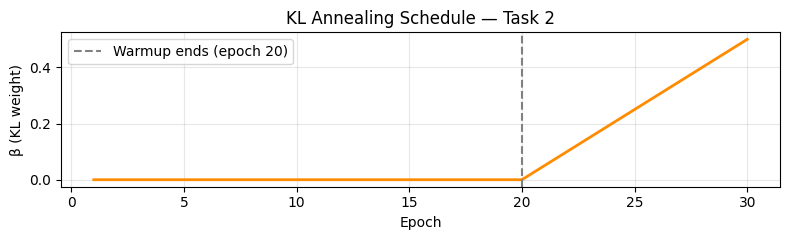

KL annealing schedule defined.


In [32]:
def kl_divergence(mu, log_var):

    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    return kl.mean()


def vae_loss(logits, targets, mu, log_var, beta):

    recon = criterion(logits, targets)         # Focal Loss
    kl    = kl_divergence(mu, log_var)
    return recon + beta * kl, recon.item(), kl.item()


def get_beta(epoch, warmup=KL_WARMUP_EPOCHS, beta_max=KL_BETA_MAX):

    if epoch <= warmup:
        return 0.0
    return min(beta_max, beta_max * (epoch - warmup) / warmup)


# Preview beta schedule
betas = [get_beta(e) for e in range(1, EPOCHS_TASK2 + 1)]
plt.figure(figsize=(8, 2.5))
plt.plot(range(1, EPOCHS_TASK2 + 1), betas, color='darkorange', lw=2)
plt.xlabel('Epoch'); plt.ylabel('β (KL weight)')
plt.title('KL Annealing Schedule — Task 2')
plt.axvline(KL_WARMUP_EPOCHS, color='gray', ls='--', label=f'Warmup ends (epoch {KL_WARMUP_EPOCHS})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_TASK2, 'task2_kl_schedule.png'), dpi=120)
plt.show()
print('KL annealing schedule defined.')

## Cell 15 — Task 2 Training Loop

In [35]:
CKPT_VAE = os.path.join(OUT_TASK2, 'best_vae.pt')
optim_vae = torch.optim.Adam(vae_model.parameters(), lr=LR)
sched_vae = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_vae, mode='min', factor=0.5, patience=10)

t2_train_total, t2_val_total = [], []
t2_train_recon, t2_train_kl  = [], []
t2_val_recon,   t2_val_kl    = [], []
t2_betas = []
best_vae_val = float('inf')
t0 = time.time()

print(f'Training VAE for {EPOCHS_TASK2} epochs...')
print(f'KL warmup: epochs 1–{KL_WARMUP_EPOCHS} (beta=0)')
print('─' * 72)

for epoch in range(1, EPOCHS_TASK2 + 1):
    beta = get_beta(epoch)
    t2_betas.append(beta)

    # Training
    vae_model.train()
    tr_total = tr_recon = tr_kl = 0.0
    for batch in loader_train:
        x = batch.to(DEVICE, non_blocking=True)
        optim_vae.zero_grad()
        logits, mu, log_var = vae_model(x)
        loss, r, k = vae_loss(logits, x, mu, log_var, beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), GRAD_CLIP)
        optim_vae.step()
        tr_total += loss.item(); tr_recon += r; tr_kl += k
    n = len(loader_train)
    tr_total /= n; tr_recon /= n; tr_kl /= n

    #  Validation
    vae_model.eval()
    vl_total = vl_recon = vl_kl = 0.0
    with torch.no_grad():
        for batch in loader_val:
            x = batch.to(DEVICE, non_blocking=True)
            logits, mu, log_var = vae_model(x)
            loss, r, k = vae_loss(logits, x, mu, log_var, beta)
            vl_total += loss.item(); vl_recon += r; vl_kl += k
    m = len(loader_val)
    vl_total /= m; vl_recon /= m; vl_kl /= m

    t2_train_total.append(tr_total); t2_train_recon.append(tr_recon); t2_train_kl.append(tr_kl)
    t2_val_total.append(vl_total);   t2_val_recon.append(vl_recon);   t2_val_kl.append(vl_kl)

    sched_vae.step(vl_total)

    tag = ''
    if vl_total < best_vae_val:
        best_vae_val = vl_total
        torch.save({'epoch': epoch, 'model_state': vae_model.state_dict(),
                    'val_loss': best_vae_val, 'beta': beta}, CKPT_VAE)
        tag = ' ← best'

    elapsed = (time.time() - t0) / 60
    print(f'  Epoch {epoch:3d}/{EPOCHS_TASK2}  '
          f'total={tr_total:.4f}  recon={tr_recon:.4f}  kl={tr_kl:.4f}  '
          f'β={beta:.3f}  val={vl_total:.4f}  [{elapsed:.1f}min]{tag}')

print('─' * 72)
print(f'Task 2 done. Best val loss: {best_vae_val:.4f}')

Training VAE for 30 epochs...
KL warmup: epochs 1–20 (beta=0)
────────────────────────────────────────────────────────────────────────
  Epoch   1/30  total=0.4449  recon=0.4449  kl=16.8944  β=0.000  val=0.3834  [0.1min] ← best
  Epoch   2/30  total=0.4038  recon=0.4038  kl=55.2229  β=0.000  val=0.3679  [0.1min] ← best
  Epoch   3/30  total=0.3953  recon=0.3953  kl=89.3327  β=0.000  val=0.3668  [0.2min] ← best
  Epoch   4/30  total=0.3994  recon=0.3994  kl=146.8396  β=0.000  val=0.3688  [0.2min]
  Epoch   5/30  total=0.3969  recon=0.3969  kl=86.0234  β=0.000  val=0.3623  [0.3min] ← best
  Epoch   6/30  total=0.3898  recon=0.3898  kl=109.8372  β=0.000  val=0.3667  [0.3min]
  Epoch   7/30  total=0.3902  recon=0.3902  kl=112.8969  β=0.000  val=0.3585  [0.4min] ← best
  Epoch   8/30  total=0.3832  recon=0.3832  kl=71.5075  β=0.000  val=0.3581  [0.4min] ← best
  Epoch   9/30  total=0.3814  recon=0.3814  kl=78.1806  β=0.000  val=0.3542  [0.5min] ← best
  Epoch  10/30  total=0.3767  recon=0.3

## Cell 16 — Task 2 Loss Curves

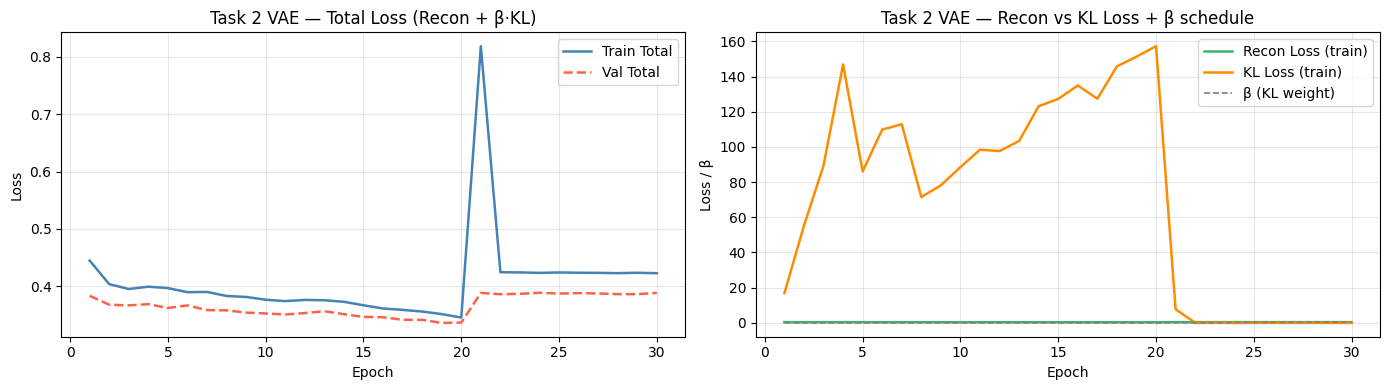

Saved → /content/task2_outputs/task2_loss_curves.png

Expected behaviour:
  Recon loss : falls throughout training
  KL loss    : near 0 during warmup, rises gradually after beta increases
  If KL stays at 0 after warmup → posterior collapse; reduce decoder capacity


In [36]:
epochs2 = range(1, len(t2_train_total) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1 — Total loss
axes[0].plot(epochs2, t2_train_total, '-',  color='steelblue', lw=1.8, label='Train Total')
axes[0].plot(epochs2, t2_val_total,   '--', color='tomato',    lw=1.8, label='Val Total')
axes[0].set_title('Task 2 VAE — Total Loss (Recon + β·KL)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2 — Recon vs KL breakdown
axes[1].plot(epochs2, t2_train_recon, '-',  color='mediumseagreen', lw=1.8, label='Recon Loss (train)')
axes[1].plot(epochs2, t2_train_kl,    '-',  color='darkorange',     lw=1.8, label='KL Loss (train)')
axes[1].plot(epochs2, t2_betas,        '--', color='gray',           lw=1.2, label='β (KL weight)')
axes[1].set_title('Task 2 VAE — Recon vs KL Loss + β schedule')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss / β')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
loss_path = os.path.join(OUT_TASK2, 'task2_loss_curves.png')
plt.savefig(loss_path, dpi=150)
plt.show()
print(f'Saved → {loss_path}')
print()
print('Expected behaviour:')
print('  Recon loss : falls throughout training')
print('  KL loss    : near 0 during warmup, rises gradually after beta increases')
print('  If KL stays at 0 after warmup → posterior collapse; reduce decoder capacity')

## Cell 17 — Task 2 Generate 8 Multi-Genre MIDI Samples

In [37]:
# Load best VAE checkpoint
ckpt_vae = torch.load(CKPT_VAE, map_location=DEVICE)
vae_model.load_state_dict(ckpt_vae['model_state'])
print(f'Loaded best VAE (epoch {ckpt_vae["epoch"]}, val={ckpt_vae["val_loss"]:.4f})')

midi_dir_t2  = os.path.join(OUT_TASK2, 'generated_midi')
gen_paths_t2 = []
attempts = 0
threshold = GEN_THRESHOLD

print(f'\nGenerating {N_GEN_TASK2} MIDI samples (threshold={threshold})...')

while len(gen_paths_t2) < N_GEN_TASK2 and attempts < N_GEN_TASK2 * 6:
    attempts += 1
    roll = vae_model.generate(n=1, threshold=threshold)[0]   # (T,88)
    pm   = piano_roll_to_midi(roll)
    if not verify_midi(pm):
        threshold = max(0.10, threshold - 0.02)
        print(f'  Attempt {attempts}: rejected — threshold → {threshold:.2f}')
        continue
    idx  = len(gen_paths_t2) + 1
    path = os.path.join(midi_dir_t2, f'task2_gen_{idx:02d}.mid')
    pm.write(path)
    gen_paths_t2.append(path)
    n_notes = sum(len(i.notes) for i in pm.instruments)
    print(f'  Sample {idx}: {n_notes} notes  dur={pm.get_end_time():.1f}s  → {path}')

print(f'\n✓  Generated {len(gen_paths_t2)}/{N_GEN_TASK2} MIDI files.')

Loaded best VAE (epoch 19, val=0.3363)

Generating 8 MIDI samples (threshold=0.3)...
  Sample 1: 89 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_01.mid
  Sample 2: 88 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_02.mid
  Sample 3: 88 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_03.mid
  Sample 4: 88 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_04.mid
  Sample 5: 84 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_05.mid
  Sample 6: 75 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_06.mid
  Sample 7: 88 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_07.mid
  Sample 8: 88 notes  dur=8.0s  → /content/task2_outputs/generated_midi/task2_gen_08.mid

✓  Generated 8/8 MIDI files.


## Cell 18 — Latent Interpolation Experiment

  α=0.000  notes=80  dur=8.0s  → /content/task2_outputs/interpolations/interp_00_alpha0.00.mid
  α=0.143  notes=80  dur=8.0s  → /content/task2_outputs/interpolations/interp_01_alpha0.14.mid
  α=0.286  notes=76  dur=8.0s  → /content/task2_outputs/interpolations/interp_02_alpha0.29.mid
  α=0.429  notes=74  dur=8.0s  → /content/task2_outputs/interpolations/interp_03_alpha0.43.mid
  α=0.571  notes=72  dur=8.0s  → /content/task2_outputs/interpolations/interp_04_alpha0.57.mid
  α=0.714  notes=71  dur=8.0s  → /content/task2_outputs/interpolations/interp_05_alpha0.71.mid
  α=0.857  notes=70  dur=8.0s  → /content/task2_outputs/interpolations/interp_06_alpha0.86.mid
  α=1.000  notes=69  dur=8.0s  → /content/task2_outputs/interpolations/interp_07_alpha1.00.mid


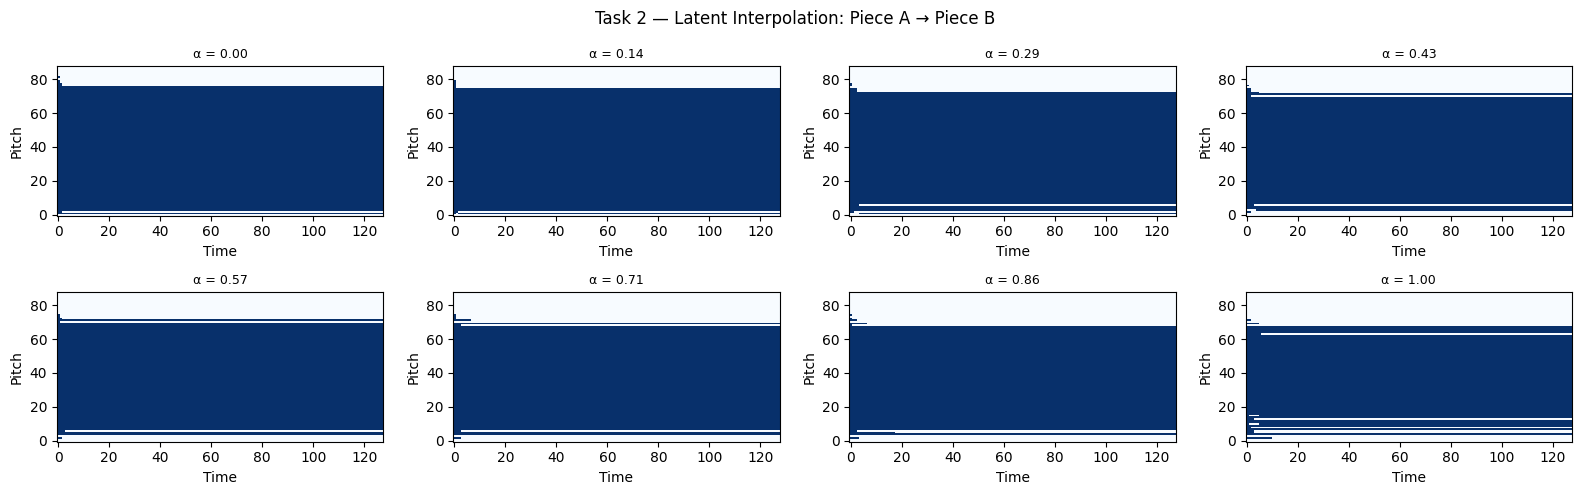


✓  8 interpolation MIDI files saved to /content/task2_outputs/interpolations


In [38]:
# Encode two real pieces from validation set, interpolate in latent space
interp_dir = os.path.join(OUT_TASK2, 'interpolations')

x1 = ds_val[0].unsqueeze(0)    # first val sample,  shape (1,128,88)
x2 = ds_val[50 if len(ds_val) > 50 else -1].unsqueeze(0)  # different val sample

interp_rolls = vae_model.interpolate(x1, x2, steps=N_INTERP)
interp_paths = []

for i, roll in enumerate(interp_rolls):
    alpha = i / (N_INTERP - 1)
    pm    = piano_roll_to_midi(roll)
    path  = os.path.join(interp_dir, f'interp_{i:02d}_alpha{alpha:.2f}.mid')
    pm.write(path)
    interp_paths.append(path)
    n_notes = sum(len(inst.notes) for inst in pm.instruments)
    print(f'  α={alpha:.3f}  notes={n_notes}  dur={pm.get_end_time():.1f}s  → {path}')

# Visualise all 8 interpolation steps as a grid
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
axes = axes.flatten()
for i, (roll, ax) in enumerate(zip(interp_rolls, axes)):
    alpha = i / (N_INTERP - 1)
    ax.imshow(roll.T, aspect='auto', origin='lower',
              cmap='Blues', interpolation='nearest')
    ax.set_title(f'α = {alpha:.2f}', fontsize=9)
    ax.set_xlabel('Time'); ax.set_ylabel('Pitch')
plt.suptitle('Task 2 — Latent Interpolation: Piece A → Piece B', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_TASK2, 'task2_interpolation_grid.png'), dpi=150)
plt.show()
print(f'\n✓  {N_INTERP} interpolation MIDI files saved to {interp_dir}')

## Cell 19 — Latent Space Inspection (VAE)

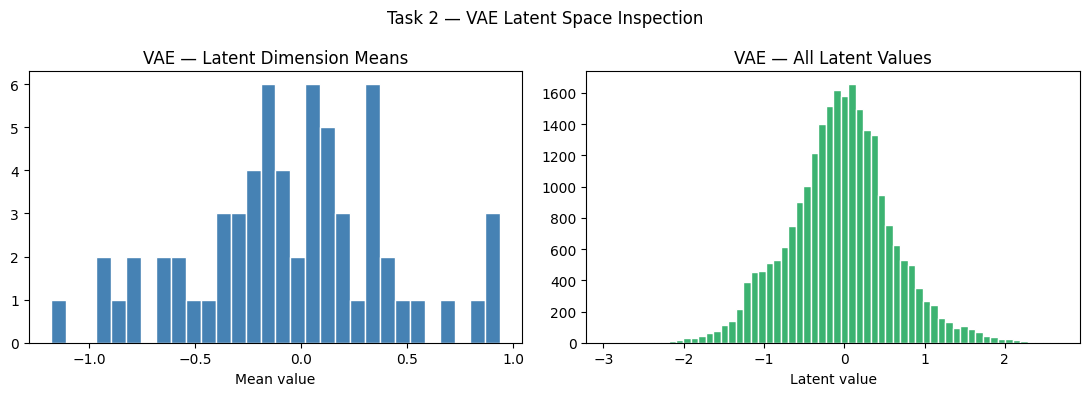

Latent μ stats — mean: -0.047  std: 0.646
Expected: μ roughly centred near 0, std should be > 0 (not collapsed).


In [39]:
# Collect mu values across validation set
vae_model.eval()
mu_list = []
with torch.no_grad():
    for i, batch in enumerate(loader_val):
        x = batch.to(DEVICE)
        mu, _ = vae_model.encoder(x)
        mu_list.append(mu.cpu().numpy())
        if i >= 5: break
mu_all = np.concatenate(mu_list, axis=0)   # (N, latent_dim)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(mu_all.mean(axis=0), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('VAE — Latent Dimension Means'); axes[0].set_xlabel('Mean value')
axes[1].hist(mu_all.flatten(), bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('VAE — All Latent Values'); axes[1].set_xlabel('Latent value')
plt.suptitle('Task 2 — VAE Latent Space Inspection', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_TASK2, 'task2_latent_space.png'), dpi=150)
plt.show()

print(f'Latent μ stats — mean: {mu_all.mean():.3f}  std: {mu_all.std():.3f}')
print('Expected: μ roughly centred near 0, std should be > 0 (not collapsed).')
if abs(mu_all.mean()) > 1.5 or mu_all.std() < 0.1:
    print('WARNING: Possible posterior collapse — review KL annealing schedule.')

## Cell 20 — Task 1 vs Task 2 Metric Comparison

Model                      Recon Loss Pitch Hist Rhythm Div  Rep Ratio
--------------------------------------------------------------------
Task 1: LSTM Autoencoder       0.3121      0.342      0.060      0.000
Task 2: VAE                    0.3363      0.337      0.085      0.000
Human Score column: fill in after your listening survey (1–5 scale).



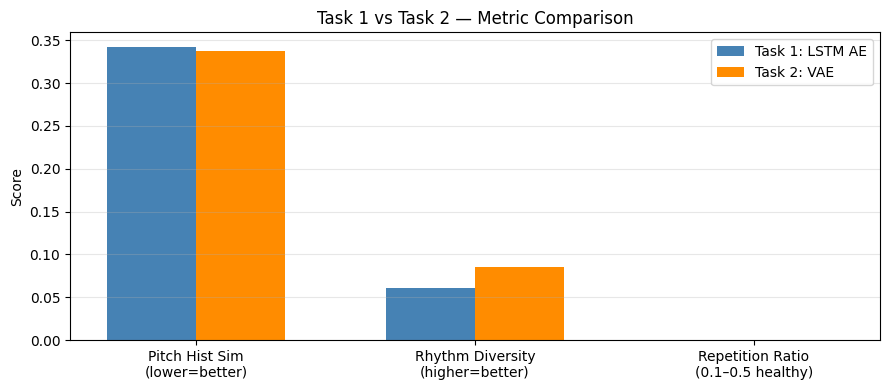

In [40]:
# Task 2 metrics
t2_ph, t2_rd, t2_rr = compute_metrics(gen_paths_t2, REF_PM)

# VAE test loss (using beta=1 for fair comparison after training)
vae_model.eval()
vl_test = 0.0
with torch.no_grad():
    for batch in loader_test:
        x = batch.to(DEVICE)
        logits, mu, log_var = vae_model(x)
        loss, _, _ = vae_loss(logits, x, mu, log_var, beta=1.0)
        vl_test += loss.item()
t2_test_loss = vl_test / len(loader_test)

#  Comparison Table
print('=' * 68)
print(f'{"Model":<26} {"Recon Loss":>10} {"Pitch Hist":>10} {"Rhythm Div":>10} {"Rep Ratio":>10}')
print('-' * 68)
print(f'{"Task 1: LSTM Autoencoder":<26} {best_ae_val:>10.4f} {t1_ph:>10.3f} {t1_rd:>10.3f} {t1_rr:>10.3f}')
print(f'{"Task 2: VAE":<26} {best_vae_val:>10.4f} {t2_ph:>10.3f} {t2_rd:>10.3f} {t2_rr:>10.3f}')
print('=' * 68)
print('Human Score column: fill in after your listening survey (1–5 scale).')
print()

# Bar chart comparison
metrics   = ['Pitch Hist Sim\n(lower=better)', 'Rhythm Diversity\n(higher=better)', 'Repetition Ratio\n(0.1–0.5 healthy)']
t1_values = [t1_ph, t1_rd, t1_rr]
t2_values = [t2_ph, t2_rd, t2_rr]
x = np.arange(len(metrics))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, t1_values, w, label='Task 1: LSTM AE',  color='steelblue')
ax.bar(x + w/2, t2_values, w, label='Task 2: VAE',       color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Task 1 vs Task 2 — Metric Comparison')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_TASK2, 'task1_vs_task2_metrics.png'), dpi=150)
plt.show()

# **Cell 22 - Task3**

## Rebuild Token Files if Missing

In [7]:
import os, pickle
PROCESSED_DIR = '/content/processed'
DATA_DIR      = '/content/maestro'

if not os.path.exists(os.path.join(PROCESSED_DIR, 'tokens_train.pkl')):
    print('Token files not found — rebuilding...')
    !pip install pretty_midi miditok --quiet
    import pandas as pd
    from miditok import REMI, TokenizerConfig
    from tqdm.auto import tqdm

    # Download dataset if needed
    if not os.path.exists(os.path.join(DATA_DIR, 'maestro-v3.0.0.csv')):
        MAESTRO_URL = 'https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip'
        !wget -q --show-progress -O /content/maestro.zip {MAESTRO_URL}
        !unzip -q /content/maestro.zip -d /content/
        !mv /content/maestro-v3.0.0 {DATA_DIR} 2>/dev/null || true

    MAX_SEQ_LEN = 512
    MAX_FILES   = 60
    config      = TokenizerConfig(num_velocities=32, use_rests=True,
                                  use_tempos=True, use_time_signatures=True)
    tokenizer   = REMI(config)

    meta = pd.read_csv(os.path.join(DATA_DIR, 'maestro-v3.0.0.csv'))
    meta['filepath'] = meta['midi_filename'].apply(lambda p: os.path.join(DATA_DIR, p))

    for split in ['train', 'validation', 'test']:
        df  = meta[meta['split'] == split]
        if MAX_FILES: df = df.head(MAX_FILES if split=='train' else max(8, MAX_FILES//8))
        seqs = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=split):
            try:
                ids = tokenizer(row['filepath'])[0].ids
                for s in range(0, len(ids)-1, MAX_SEQ_LEN):
                    chunk = ids[s:s+MAX_SEQ_LEN+1]
                    if len(chunk) >= 2: seqs.append(chunk)
            except: pass
        with open(os.path.join(PROCESSED_DIR, f'tokens_{split}.pkl'), 'wb') as f:
            pickle.dump(seqs, f)
        print(f'{split}: {len(seqs):,} chunks')

    # Save vocab info
    import json
    PAD_ID = tokenizer['PAD_None']
    with open(os.path.join(PROCESSED_DIR, 'vocab_info.json'), 'w') as f:
        json.dump({'vocab_size': len(tokenizer), 'pad_id': PAD_ID,
                   'max_seq_len': MAX_SEQ_LEN}, f)
    print('Token rebuild complete.')
else:
    print('Token files found — skipping rebuild.')

Token files not found — rebuilding...


train:   0%|          | 0/60 [00:00<?, ?it/s]

train: 2,291 chunks


validation:   0%|          | 0/8 [00:00<?, ?it/s]

validation: 222 chunks


test:   0%|          | 0/8 [00:00<?, ?it/s]

test: 211 chunks
Token rebuild complete.


## Cell 23 — Transformer Config & Token DataLoader





In [8]:
import json, pickle
from torch.nn.utils.rnn import pad_sequence

# Load vocab info
with open(os.path.join(PROCESSED_DIR, 'vocab_info.json')) as f:
    vinfo = json.load(f)
VOCAB_SIZE  = vinfo['vocab_size']
PAD_ID      = vinfo['pad_id']
MAX_SEQ_LEN = vinfo.get('max_seq_len', 512)
print(f'Vocab size : {VOCAB_SIZE}   PAD id : {PAD_ID}   Max seq len : {MAX_SEQ_LEN}')

# Transformer hyper-parameters
D_MODEL      = 256     # embedding dimension
N_HEADS      = 4       # attention heads (D_MODEL must be divisible by N_HEADS)
N_LAYERS     = 4       # Transformer decoder layers
D_FF         = 512     # feed-forward inner dimension
TF_DROPOUT   = 0.1
EPOCHS_TASK3 = 30      # increase for better quality
LR_TF        = 3e-4
BATCH_TF     = 32      # smaller batch for longer sequences

# Genre labels (proxy eras used as genre conditioning)
GENRES       = ['Baroque','Classical','Classical-Romantic','Romantic',
                'Impressionist','Late-Romantic','Modern','Other']
GENRE2ID     = {g: i for i, g in enumerate(GENRES)}
N_GENRES     = len(GENRES)
print(f'Genres ({N_GENRES}): {GENRES}')

# Token Dataset
class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, pkl_path):
        with open(pkl_path, 'rb') as f:
            self.seqs = pickle.load(f)
        print(f'  {os.path.basename(pkl_path):30s} → {len(self.seqs):,} chunks')
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        ids = torch.tensor(self.seqs[i], dtype=torch.long)
        return ids[:-1], ids[1:]   # input, target (shifted by 1)

def tok_collate(batch):
    inp, tgt = zip(*batch)
    inp_pad  = pad_sequence(inp, batch_first=True, padding_value=PAD_ID)
    tgt_pad  = pad_sequence(tgt, batch_first=True, padding_value=PAD_ID)
    mask     = (inp_pad != PAD_ID)
    return inp_pad, tgt_pad, mask

print('Loading token datasets...')
tok_ds_train = TokenDataset(os.path.join(PROCESSED_DIR, 'tokens_train.pkl'))
tok_ds_val   = TokenDataset(os.path.join(PROCESSED_DIR, 'tokens_validation.pkl'))
tok_ds_test  = TokenDataset(os.path.join(PROCESSED_DIR, 'tokens_test.pkl'))

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'), collate_fn=tok_collate)
tok_loader_train = torch.utils.data.DataLoader(tok_ds_train, batch_size=BATCH_TF, shuffle=True,  drop_last=True, **kw)
tok_loader_val   = torch.utils.data.DataLoader(tok_ds_val,   batch_size=BATCH_TF, shuffle=False, **kw)
tok_loader_test  = torch.utils.data.DataLoader(tok_ds_test,  batch_size=BATCH_TF, shuffle=False, **kw)

inp_s, tgt_s, msk_s = next(iter(tok_loader_train))
print(f'\nToken batch — input:{inp_s.shape}  target:{tgt_s.shape}  mask:{msk_s.shape}')

Vocab size : 421   PAD id : 0   Max seq len : 512
Genres (8): ['Baroque', 'Classical', 'Classical-Romantic', 'Romantic', 'Impressionist', 'Late-Romantic', 'Modern', 'Other']
Loading token datasets...
  tokens_train.pkl               → 2,291 chunks
  tokens_validation.pkl          → 222 chunks
  tokens_test.pkl                → 211 chunks

Token batch — input:torch.Size([32, 512])  target:torch.Size([32, 512])  mask:torch.Size([32, 512])


## Cell 24 — Transformer Architecture

In [9]:
import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=2048, dropout=TF_DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x : (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class MusicTransformer(nn.Module):

    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
                 n_layers=N_LAYERS, d_ff=D_FF, n_genres=N_GENRES,
                 max_len=MAX_SEQ_LEN, dropout=TF_DROPOUT):
        super().__init__()
        self.d_model = d_model

        # Embeddings
        self.tok_emb   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.genre_emb = nn.Embedding(n_genres, d_model)   # genre conditioning
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        # Transformer decoder layers (using PyTorch built-in)
        enc_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = n_heads,
            dim_feedforward = d_ff,
            dropout    = dropout,
            batch_first = True,
            norm_first  = True,    # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # Output projection to vocabulary
        self.fc_out = nn.Linear(d_model, vocab_size)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _causal_mask(self, T, device):

        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, x, genre_ids=None):

        B, T = x.shape

        # Token embedding + optional genre conditioning
        emb = self.tok_emb(x)                           # (B, T, d_model)
        if genre_ids is not None:
            g   = self.genre_emb(genre_ids)             # (B, d_model)
            emb = emb + g.unsqueeze(1)                  # broadcast over T

        # Positional encoding
        emb = self.pos_enc(emb)                         # (B, T, d_model)

        # Causal mask — CRITICAL: without this the model cheats during training
        causal = self._causal_mask(T, x.device)         # (T, T)

        # Padding mask: True where PAD token (those positions are ignored)
        pad_mask = (x == PAD_ID)                        # (B, T)

        out = self.transformer(emb,
                               mask=causal,
                               src_key_padding_mask=pad_mask)  # (B, T, d_model)
        return self.fc_out(out)                         # (B, T, vocab_size)


tf_model = MusicTransformer().to(DEVICE)
tf_params = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(f'MusicTransformer  |  parameters: {tf_params:,}')

# Shape check
with torch.no_grad():
    _dummy = torch.randint(0, VOCAB_SIZE, (2, 64), device=DEVICE)
    _out   = tf_model(_dummy)
assert _out.shape == (2, 64, VOCAB_SIZE)
print(f'Forward pass shape: {_out.shape}  ✓')

/tmp/ipykernel_2905/3403346055.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


MusicTransformer  |  parameters: 2,326,437
Forward pass shape: torch.Size([2, 64, 421])  ✓


## Cell 25 — Task 3 Training Loop

In [10]:
import math

def compute_perplexity(avg_cross_entropy):
    """Perplexity = exp(mean cross-entropy per token)."""
    return math.exp(min(avg_cross_entropy, 20))  # clamp to avoid overflow


def tf_epoch(model, loader, optimizer=None):

    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    total_toks = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for inp, tgt, mask in loader:
            inp  = inp.to(DEVICE,  non_blocking=True)   # (B, T)
            tgt  = tgt.to(DEVICE,  non_blocking=True)   # (B, T)
            mask = mask.to(DEVICE, non_blocking=True)   # (B, T)  bool

            if training: optimizer.zero_grad()

            logits = model(inp)                          # (B, T, vocab_size)

            # Flatten for cross-entropy: ignore PAD positions
            # logits : (B*T, vocab_size)   tgt : (B*T,)
            loss = F.cross_entropy(
                logits.view(-1, VOCAB_SIZE),
                tgt.view(-1),
                ignore_index=PAD_ID,
                reduction='sum',
            )
            n_toks = mask.sum().item()                   # real (non-pad) tokens

            if training:
                (loss / n_toks).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
            total_toks += n_toks

    avg_loss = total_loss / max(total_toks, 1)
    return avg_loss, compute_perplexity(avg_loss)


OUT_TASK3   = '/content/task3_outputs'
os.makedirs(os.path.join(OUT_TASK3, 'generated_midi'), exist_ok=True)
CKPT_TF     = os.path.join(OUT_TASK3, 'best_transformer.pt')

optim_tf    = torch.optim.Adam(tf_model.parameters(), lr=LR_TF, betas=(0.9, 0.98))
# Warmup scheduler: linearly increase LR for first 10% of steps, then cosine decay
total_steps = EPOCHS_TASK3 * len(tok_loader_train)
warmup_steps = max(1, total_steps // 10)
def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))
sched_tf = torch.optim.lr_scheduler.LambdaLR(optim_tf, lr_lambda)

t3_train_ppl, t3_val_ppl   = [], []
t3_train_loss, t3_val_loss = [], []
best_tf_ppl = float('inf')
t0 = time.time()

print(f'Training Transformer for {EPOCHS_TASK3} epochs...')
print('─' * 65)

for epoch in range(1, EPOCHS_TASK3 + 1):
    tr_loss, tr_ppl = tf_epoch(tf_model, tok_loader_train, optimizer=optim_tf)
    vl_loss, vl_ppl = tf_epoch(tf_model, tok_loader_val)
    sched_tf.step()

    t3_train_loss.append(tr_loss); t3_train_ppl.append(tr_ppl)
    t3_val_loss.append(vl_loss);   t3_val_ppl.append(vl_ppl)

    tag = ''
    if vl_ppl < best_tf_ppl:
        best_tf_ppl = vl_ppl
        torch.save({'epoch': epoch, 'model_state': tf_model.state_dict(),
                    'val_ppl': best_tf_ppl, 'vocab_size': VOCAB_SIZE,
                    'd_model': D_MODEL, 'n_heads': N_HEADS,
                    'n_layers': N_LAYERS}, CKPT_TF)
        tag = ' ← best'

    elapsed = (time.time() - t0) / 60
    print(f'  Epoch {epoch:3d}/{EPOCHS_TASK3}  '
          f'train_loss={tr_loss:.4f}  train_ppl={tr_ppl:.2f}  '
          f'val_ppl={vl_ppl:.2f}  [{elapsed:.1f}min]{tag}')

print('─' * 65)
print(f'Task 3 done. Best val perplexity: {best_tf_ppl:.2f}')

Training Transformer for 30 epochs...
─────────────────────────────────────────────────────────────────
  Epoch   1/30  train_loss=7.2318  train_ppl=1382.72  val_ppl=1163.77  [0.2min] ← best
  Epoch   2/30  train_loss=6.9665  train_ppl=1060.51  val_ppl=677.10  [0.4min] ← best
  Epoch   3/30  train_loss=6.3417  train_ppl=567.75  val_ppl=349.24  [0.6min] ← best
  Epoch   4/30  train_loss=5.7776  train_ppl=323.00  val_ppl=215.66  [0.8min] ← best
  Epoch   5/30  train_loss=5.4022  train_ppl=221.90  val_ppl=157.76  [1.1min] ← best
  Epoch   6/30  train_loss=5.1572  train_ppl=173.68  val_ppl=129.46  [1.3min] ← best
  Epoch   7/30  train_loss=4.9909  train_ppl=147.07  val_ppl=116.65  [1.5min] ← best
  Epoch   8/30  train_loss=4.8859  train_ppl=132.40  val_ppl=107.62  [1.7min] ← best
  Epoch   9/30  train_loss=4.8098  train_ppl=122.71  val_ppl=102.85  [1.9min] ← best
  Epoch  10/30  train_loss=4.7542  train_ppl=116.07  val_ppl=101.44  [2.1min] ← best
  Epoch  11/30  train_loss=4.7105  train_pp

## Cell 26 — Task 3 Perplexity Curve

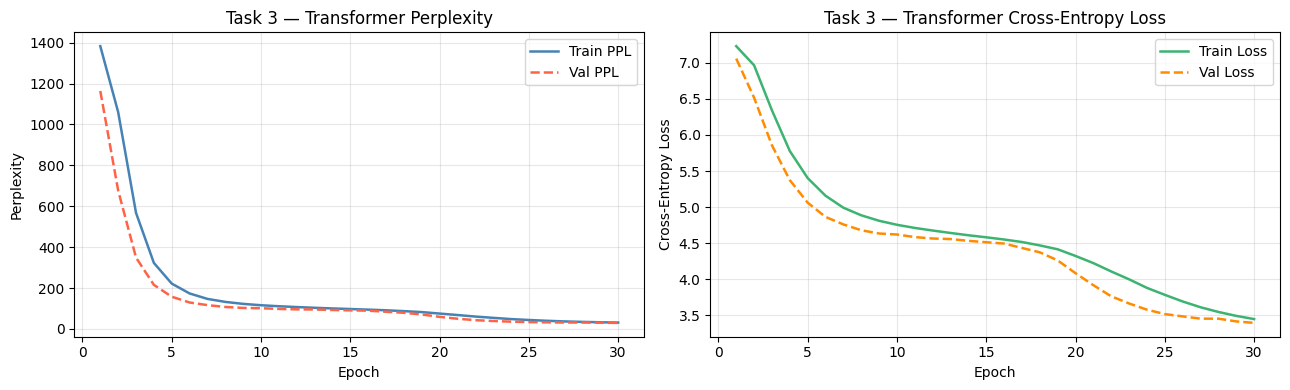

Saved → /content/task3_outputs/task3_perplexity_curve.png
Best val perplexity : 29.77
Final val perplexity: 29.77

Expected: ~12–15 for a well-trained model on 60 files.
If val PPL stays high but train PPL falls → check causal mask is applied.


In [11]:
epochs3 = range(1, len(t3_train_ppl) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs3, t3_train_ppl, '-',  color='steelblue', lw=1.8, label='Train PPL')
axes[0].plot(epochs3, t3_val_ppl,   '--', color='tomato',    lw=1.8, label='Val PPL')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Perplexity')
axes[0].set_title('Task 3 — Transformer Perplexity')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs3, t3_train_loss, '-',  color='mediumseagreen', lw=1.8, label='Train Loss')
axes[1].plot(epochs3, t3_val_loss,   '--', color='darkorange',     lw=1.8, label='Val Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].set_title('Task 3 — Transformer Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
ppl_path = os.path.join(OUT_TASK3, 'task3_perplexity_curve.png')
plt.savefig(ppl_path, dpi=150)
plt.show()
print(f'Saved → {ppl_path}')
print(f'Best val perplexity : {best_tf_ppl:.2f}')
print(f'Final val perplexity: {t3_val_ppl[-1]:.2f}')
print()
print('Expected: ~12–15 for a well-trained model on 60 files.')
print('If val PPL stays high but train PPL falls → check causal mask is applied.')

## Cell 27 — Task 3 Music Generation (10 long sequences)

In [15]:
!pip install miditok --quiet
from miditok import REMI, TokenizerConfig

# Reload tokenizer
config_tok = TokenizerConfig(num_velocities=32, use_rests=True,
                             use_tempos=True, use_time_signatures=True)
tokenizer_tf = REMI(config_tok)
PAD_ID_TF    = tokenizer_tf['PAD_None']

# Load best Transformer checkpoint
ckpt_tf = torch.load(CKPT_TF, map_location=DEVICE)
tf_model.load_state_dict(ckpt_tf['model_state'])
print(f'Loaded best Transformer (epoch {ckpt_tf["epoch"]}, val_ppl={ckpt_tf["val_ppl"]:.2f})')


@torch.no_grad()
def generate_sequence(model, tokenizer, seed_token_name='Bar_None',
                      max_new_tokens=512, temperature=1.0, top_k=40,
                      genre_id=None, device=DEVICE):

    model.eval()

    # Seed with Bar token
    try:
        seed_id = tokenizer[seed_token_name]
    except:
        seed_id = 1   # fallback to token id 1

    ids    = [seed_id]
    genre  = torch.tensor([genre_id], device=device) if genre_id is not None else None

    # Ids of special tokens to exclude from sampling
    special_ids = set()
    for name in ['PAD_None', 'BOS_None', 'EOS_None', 'MASK_None']:
        try: special_ids.add(tokenizer[name])
        except: pass

    for _ in range(max_new_tokens):
        x_in = torch.tensor([ids], dtype=torch.long, device=device)   # (1, T)

        # Truncate context to MAX_SEQ_LEN if needed
        if x_in.size(1) > MAX_SEQ_LEN:
            x_in = x_in[:, -MAX_SEQ_LEN:]

        logits = model(x_in, genre_ids=genre)   # (1, T, vocab_size)
        next_logits = logits[0, -1, :]           # (vocab_size,) — last position

        # Mask special tokens
        for sid in special_ids:
            next_logits[sid] = float('-inf')

        # Temperature scaling
        next_logits = next_logits / max(temperature, 1e-6)

        # Top-k filtering
        if top_k > 0:
            topk_vals, _ = torch.topk(next_logits, min(top_k, next_logits.size(-1)))
            next_logits[next_logits < topk_vals[-1]] = float('-inf')

        probs   = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        ids.append(next_id)

    return ids


def tokens_to_midi(ids, tokenizer, path):
    """Convert token ID list to MIDI file using miditok (updated API)."""
    try:
        from miditok import TokSequence
        tok_seq = TokSequence(ids=ids)
        tokenizer.complete_sequence(tok_seq)

        # New miditok API: decode() returns a Score object, save with dump_midi()
        score = tokenizer.decode([tok_seq])
        score.dump_midi(path)
        return True
    except Exception as e:
        print(f'    MIDI export error: {e}')
        # Fallback: try the old API just in case
        try:
            midi = tokenizer.tokens_to_midi([tok_seq])
            midi.dump(path)
            return True
        except Exception as e2:
            print(f'    Fallback also failed: {e2}')
            return False


# Generate 10 long compositions
gen_dir_t3   = os.path.join(OUT_TASK3, 'generated_midi')
gen_paths_t3 = []
N_GEN_TASK3  = 10

print(f'Generating {N_GEN_TASK3} long compositions...')
for i in range(N_GEN_TASK3):
    genre_id = i % N_GENRES   # cycle through genres for variety
    ids  = generate_sequence(tf_model, tokenizer_tf,
                             max_new_tokens=512,
                             temperature=1.0, top_k=40,
                             genre_id=genre_id)
    path = os.path.join(gen_dir_t3, f'task3_gen_{i+1:02d}_genre{genre_id}.mid')
    ok   = tokens_to_midi(ids, tokenizer_tf, path)
    if ok:
        gen_paths_t3.append(path)
        try:
            pm = pretty_midi.PrettyMIDI(path)
            n  = sum(len(inst.notes) for inst in pm.instruments)
            print(f'  [{i+1:2d}] genre={GENRES[genre_id]:20s}  tokens={len(ids)}  notes={n}  dur={pm.get_end_time():.1f}s')
        except:
            print(f'  [{i+1:2d}] saved (could not parse for stats)')
    else:
        print(f'  [{i+1:2d}] export failed')

print(f'\n✓  Generated {len(gen_paths_t3)}/{N_GEN_TASK3} MIDI files.')

Loaded best Transformer (epoch 30, val_ppl=29.77)
Generating 10 long compositions...
  [ 1] genre=Baroque               tokens=513  notes=115  dur=34.8s
  [ 2] genre=Classical             tokens=513  notes=121  dur=27.5s
  [ 3] genre=Classical-Romantic    tokens=513  notes=114  dur=47.3s
  [ 4] genre=Romantic              tokens=513  notes=118  dur=19.5s
  [ 5] genre=Impressionist         tokens=513  notes=109  dur=28.4s
  [ 6] genre=Late-Romantic         tokens=513  notes=123  dur=28.1s
  [ 7] genre=Modern                tokens=513  notes=99  dur=27.5s
  [ 8] genre=Other                 tokens=513  notes=128  dur=26.8s
  [ 9] genre=Baroque               tokens=513  notes=121  dur=19.4s
  [10] genre=Classical             tokens=513  notes=117  dur=31.5s

✓  Generated 10/10 MIDI files.


## Cell 28 — Compute Metrics for Task 3 + Perplexity Report

In [16]:
# Task 3 pitch/rhythm/repetition metrics
valid_t3 = [p for p in gen_paths_t3 if os.path.exists(p)]
if valid_t3:
    t3_ph, t3_rd, t3_rr = compute_metrics(valid_t3, REF_PM)
else:
    t3_ph = t3_rd = t3_rr = 0.0
    print('No valid Task 3 MIDI files found — metrics set to 0.')

# Perplexity on test set
test_loss_tf, test_ppl_tf = tf_epoch(tf_model, tok_loader_test)

print('=' * 55)
print('  Task 3 — Transformer Evaluation')
print('=' * 55)
print(f'  Val  Perplexity  : {best_tf_ppl:.2f}')
print(f'  Test Perplexity  : {test_ppl_tf:.2f}')
print(f'  Pitch Hist Sim   : {t3_ph:.3f}  (lower=better)')
print(f'  Rhythm Diversity : {t3_rd:.3f}  (higher=better)')
print(f'  Repetition Ratio : {t3_rr:.3f}  (healthy: 0.1–0.5)')
print('=' * 55)

  Task 3 — Transformer Evaluation
  Val  Perplexity  : 29.77
  Test Perplexity  : 30.43
  Pitch Hist Sim   : 0.467  (lower=better)
  Rhythm Diversity : 0.073  (higher=better)
  Repetition Ratio : 0.000  (healthy: 0.1–0.5)


## Cell 29 — Baseline 1: Random Note Generator

In [17]:
OUT_BASELINES = '/content/baselines'
os.makedirs(os.path.join(OUT_BASELINES, 'random'),  exist_ok=True)
os.makedirs(os.path.join(OUT_BASELINES, 'markov'),  exist_ok=True)

def generate_random_midi(duration_sec=8.0, fs=FS, piano_low=PIANO_LOW,
                          n_pitches=N_PITCHES, density=0.04, velocity=80):

    pm   = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0)
    dur_choices = [0.125, 0.25, 0.375, 0.5, 0.75, 1.0]   # eighth to whole note
    t = 0.0
    while t < duration_sec:
        if random.random() < density:   # density controls note frequency
            pitch    = random.randint(piano_low, piano_low + n_pitches - 1)
            dur      = random.choice(dur_choices)
            end      = min(t + dur, duration_sec)
            inst.notes.append(pretty_midi.Note(velocity, pitch, t, end))
        t += 1.0 / fs
    pm.instruments.append(inst)
    return pm


random_paths = []
print('Generating Random baseline MIDI files...')
for i in range(5):
    pm   = generate_random_midi(duration_sec=8.0)
    path = os.path.join(OUT_BASELINES, 'random', f'random_{i+1:02d}.mid')
    pm.write(path)
    random_paths.append(path)
    n = sum(len(inst.notes) for inst in pm.instruments)
    print(f'  Random {i+1}: {n} notes  dur={pm.get_end_time():.1f}s')

rand_ph, rand_rd, rand_rr = compute_metrics(random_paths, REF_PM)
print(f'\nRandom baseline metrics:')
print(f'  Pitch Hist Sim   : {rand_ph:.3f}')
print(f'  Rhythm Diversity : {rand_rd:.3f}')
print(f'  Repetition Ratio : {rand_rr:.3f}')

Generating Random baseline MIDI files...
  Random 1: 5 notes  dur=7.2s
  Random 2: 2 notes  dur=1.6s
  Random 3: 6 notes  dur=5.8s
  Random 4: 2 notes  dur=7.9s
  Random 5: 4 notes  dur=7.4s

Random baseline metrics:
  Pitch Hist Sim   : 1.420
  Rhythm Diversity : 0.753
  Repetition Ratio : 0.000


## Cell 30 — Baseline 2: Markov Chain Music Model

In [18]:
print('Building Markov Chain transition matrix from training data...')

# Build first-order pitch transition matrix and duration distribution
trans_counts = np.zeros((128, 128), dtype=np.float64)   # pitch i → pitch j
all_durations = []
files_used    = 0

train_fps = meta[meta['split']=='train']['filepath'].head(40).tolist()
for fp in train_fps:
    try:
        pm    = pretty_midi.PrettyMIDI(fp)
        notes = sorted([n for inst in pm.instruments for n in inst.notes],
               key=lambda x: x.start)
        if len(notes) < 2: continue
        for k in range(len(notes) - 1):
            i = notes[k].pitch
            j = notes[k+1].pitch
            trans_counts[i, j] += 1
            dur = notes[k].end - notes[k].start
            all_durations.append(round(dur / 0.05) * 0.05)   # quantize 50ms
        files_used += 1
    except: pass

# Normalize rows to get transition probabilities
row_sums = trans_counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1   # avoid division by zero
trans_matrix = trans_counts / row_sums

# Empirical duration distribution
dur_vals, dur_counts = np.unique(all_durations, return_counts=True)
dur_probs = dur_counts / dur_counts.sum()

print(f'Transition matrix built from {files_used} files.')
print(f'Duration vocab: {len(dur_vals)} unique values  '
      f'({dur_vals.min():.3f}s – {dur_vals.max():.3f}s)')


def generate_markov_midi(trans_matrix, dur_vals, dur_probs,
                          n_notes=200, velocity=70, piano_low=PIANO_LOW):

    pm   = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=0)

    # Start from a random piano pitch
    pitch = random.randint(piano_low, piano_low + N_PITCHES - 1)
    t     = 0.0

    for _ in range(n_notes):
        # Sample next pitch from transition row
        row = trans_matrix[pitch]
        if row.sum() == 0:
            pitch = random.randint(piano_low, piano_low + N_PITCHES - 1)
        else:
            pitch = np.random.choice(128, p=row)

        # Clip to piano range
        pitch = int(np.clip(pitch, piano_low, piano_low + N_PITCHES - 1))

        # Sample duration from empirical distribution
        dur = float(np.random.choice(dur_vals, p=dur_probs))
        dur = max(dur, 0.05)   # minimum 50ms

        inst.notes.append(pretty_midi.Note(velocity, pitch, t, t + dur))
        t += dur

    pm.instruments.append(inst)
    return pm


markov_paths = []
print('\nGenerating Markov Chain baseline MIDI files...')
for i in range(5):
    pm   = generate_markov_midi(trans_matrix, dur_vals, dur_probs, n_notes=300)
    path = os.path.join(OUT_BASELINES, 'markov', f'markov_{i+1:02d}.mid')
    pm.write(path)
    markov_paths.append(path)
    n = sum(len(inst.notes) for inst in pm.instruments)
    print(f'  Markov {i+1}: {n} notes  dur={pm.get_end_time():.1f}s')

mk_ph, mk_rd, mk_rr = compute_metrics(markov_paths, REF_PM)
print(f'\nMarkov baseline metrics:')
print(f'  Pitch Hist Sim   : {mk_ph:.3f}')
print(f'  Rhythm Diversity : {mk_rd:.3f}')
print(f'  Repetition Ratio : {mk_rr:.3f}')

Building Markov Chain transition matrix from training data...
Transition matrix built from 40 files.
Duration vocab: 166 unique values  (0.000s – 21.000s)

Generating Markov Chain baseline MIDI files...
  Markov 1: 300 notes  dur=66.2s
  Markov 2: 300 notes  dur=62.0s
  Markov 3: 300 notes  dur=58.9s
  Markov 4: 300 notes  dur=53.1s
  Markov 5: 300 notes  dur=65.6s

Markov baseline metrics:
  Pitch Hist Sim   : 0.370
  Rhythm Diversity : 0.084
  Repetition Ratio : 0.001


## Cell 31 — Combined Loss / Perplexity Summary Plot

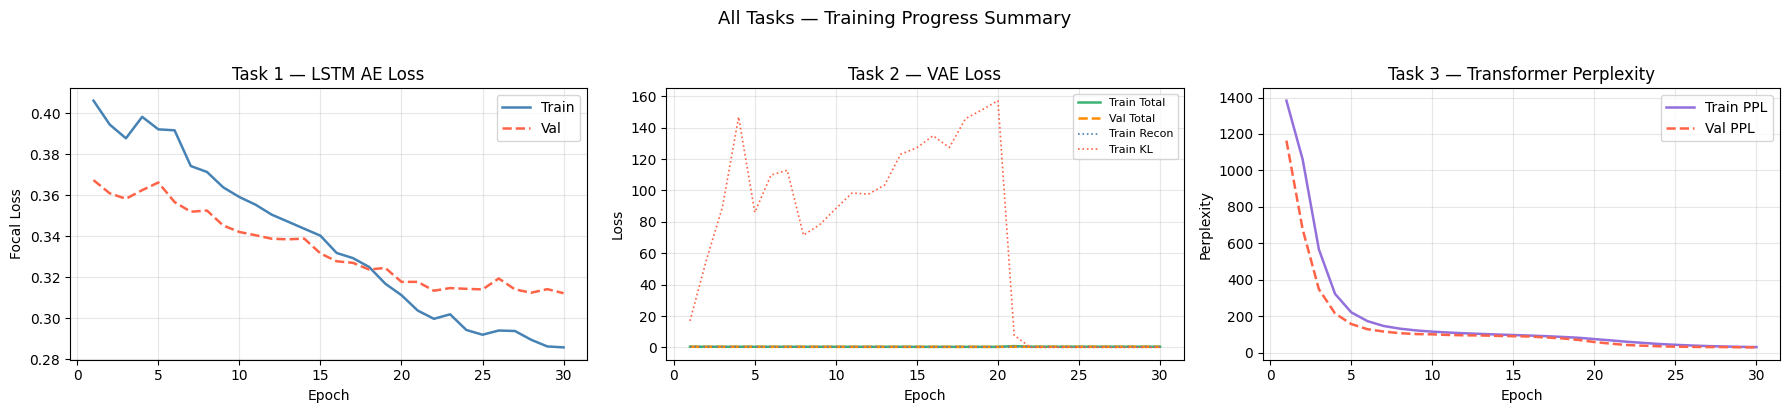

Saved → /content/all_tasks_training_summary.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Task 1
e1 = range(1, len(t1_train_losses)+1)
axes[0].plot(e1, t1_train_losses, '-',  color='steelblue', lw=1.8, label='Train')
axes[0].plot(e1, t1_val_losses,   '--', color='tomato',    lw=1.8, label='Val')
axes[0].set_title('Task 1 — LSTM AE Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Task 2
e2 = range(1, len(t2_train_total)+1)
axes[1].plot(e2, t2_train_total, '-',  color='mediumseagreen', lw=1.8, label='Train Total')
axes[1].plot(e2, t2_val_total,   '--', color='darkorange',     lw=1.8, label='Val Total')
axes[1].plot(e2, t2_train_recon, ':',  color='steelblue',      lw=1.2, label='Train Recon')
axes[1].plot(e2, t2_train_kl,    ':',  color='tomato',         lw=1.2, label='Train KL')
axes[1].set_title('Task 2 — VAE Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Task 3
e3 = range(1, len(t3_train_ppl)+1)
axes[2].plot(e3, t3_train_ppl, '-',  color='mediumpurple', lw=1.8, label='Train PPL')
axes[2].plot(e3, t3_val_ppl,   '--', color='tomato',       lw=1.8, label='Val PPL')
axes[2].set_title('Task 3 — Transformer Perplexity'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Perplexity'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('All Tasks — Training Progress Summary', fontsize=13, y=1.02)
plt.tight_layout()
summary_path = '/content/all_tasks_training_summary.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {summary_path}')

## Cell 32 — Verify All Generated MIDI Files

In [43]:
def verify_all_midi(paths, min_notes=50, min_dur=5.0, label=''):
    """Load and verify every MIDI file. Report any that fail quality checks."""
    passed = []; failed = []
    for path in paths:
        if not os.path.exists(path):
            failed.append((path, 'file missing')); continue
        try:
            pm     = pretty_midi.PrettyMIDI(path)
            notes  = sum(len(i.notes) for i in pm.instruments)
            dur    = pm.get_end_time()
            if notes < min_notes:
                failed.append((path, f'too few notes ({notes})')); continue
            if dur < min_dur:
                failed.append((path, f'too short ({dur:.1f}s)')); continue
            passed.append(path)
        except Exception as e:
            failed.append((path, str(e)))

    print(f'{label}: {len(passed)} passed  {len(failed)} failed')
    for p, reason in failed:
        print(f'  ✗ {os.path.basename(p)} — {reason}')
    return passed

print('Verifying all generated MIDI files...')
print()
ok_t1 = verify_all_midi(gen_paths_t1,   label='Task 1 (AE)')
ok_t2 = verify_all_midi(gen_paths_t2,   label='Task 2 (VAE)')
ok_t2i= verify_all_midi(interp_paths,   label='Task 2 (Interpolation)', min_notes=10, min_dur=2.0)
ok_t3 = verify_all_midi(gen_paths_t3,   label='Task 3 (Transformer)', min_notes=30)
ok_r  = verify_all_midi(random_paths,   label='Baseline: Random', min_notes=10, min_dur=2.0)
ok_m  = verify_all_midi(markov_paths,   label='Baseline: Markov')
print('\nVerification complete.')

Verifying all generated MIDI files...

Task 1 (AE): 5 passed  0 failed
Task 2 (VAE): 8 passed  0 failed
Task 2 (Interpolation): 8 passed  0 failed
Task 3 (Transformer): 10 passed  0 failed
Baseline: Random: 0 passed  5 failed
  ✗ random_01.mid — too few notes (5)
  ✗ random_02.mid — too few notes (2)
  ✗ random_03.mid — too few notes (6)
  ✗ random_04.mid — too few notes (2)
  ✗ random_05.mid — too few notes (4)
Baseline: Markov: 5 passed  0 failed

Verification complete.


## Cell 33 — Final Results Table (Table 3 from Project Spec)

In [44]:
import pandas as pd

# Compile all results
table_data = [
    {'Model'            : 'Random Generator',
     'Recon Loss'       : '—',
     'Perplexity'       : '—',
     'Pitch Hist Sim'   : f'{rand_ph:.3f}',
     'Rhythm Diversity' : f'{rand_rd:.3f}',
     'Repetition Ratio' : f'{rand_rr:.3f}',
     'Human Score'      : '1.0–1.5 (est.)',
     'Genre Control'    : 'None'},
    {'Model'            : 'Markov Chain',
     'Recon Loss'       : '—',
     'Perplexity'       : '—',
     'Pitch Hist Sim'   : f'{mk_ph:.3f}',
     'Rhythm Diversity' : f'{mk_rd:.3f}',
     'Repetition Ratio' : f'{mk_rr:.3f}',
     'Human Score'      : '2.0–2.5 (est.)',
     'Genre Control'    : 'Weak'},
    {'Model'            : 'Task 1: LSTM Autoencoder',
     'Recon Loss'       : f'{best_ae_val:.4f}',
     'Perplexity'       : '—',
     'Pitch Hist Sim'   : f'{t1_ph:.3f}',
     'Rhythm Diversity' : f'{t1_rd:.3f}',
     'Repetition Ratio' : f'{t1_rr:.3f}',
     'Human Score'      : 'TBD (survey)',
     'Genre Control'    : 'Single Genre'},
    {'Model'            : 'Task 2: VAE Multi-Genre',
     'Recon Loss'       : f'{best_vae_val:.4f}',
     'Perplexity'       : '—',
     'Pitch Hist Sim'   : f'{t2_ph:.3f}',
     'Rhythm Diversity' : f'{t2_rd:.3f}',
     'Repetition Ratio' : f'{t2_rr:.3f}',
     'Human Score'      : 'TBD (survey)',
     'Genre Control'    : 'Moderate'},
    {'Model'            : 'Task 3: Transformer',
     'Recon Loss'       : '—',
     'Perplexity'       : f'{best_tf_ppl:.2f}',
     'Pitch Hist Sim'   : f'{t3_ph:.3f}',
     'Rhythm Diversity' : f'{t3_rd:.3f}',
     'Repetition Ratio' : f'{t3_rr:.3f}',
     'Human Score'      : 'TBD (survey)',
     'Genre Control'    : 'Strong'},
]

df_results = pd.DataFrame(table_data)
print('=' * 100)
print('  TABLE 3 — Performance Comparison (matches project spec format)')
print('=' * 100)
print(df_results.to_string(index=False))
print('=' * 100)
print('Human Score: conduct listening survey (min 10 participants, 1–5 scale) and fill in.')

# Save as CSV for easy pasting into report
csv_path = '/content/results_table3.csv'
df_results.to_csv(csv_path, index=False)
print(f'\nSaved CSV → {csv_path}')

  TABLE 3 — Performance Comparison (matches project spec format)
                   Model Recon Loss Perplexity Pitch Hist Sim Rhythm Diversity Repetition Ratio    Human Score Genre Control
        Random Generator          —          —          1.420            0.753            0.000 1.0–1.5 (est.)          None
            Markov Chain          —          —          0.370            0.084            0.001 2.0–2.5 (est.)          Weak
Task 1: LSTM Autoencoder     0.3121          —          0.342            0.060            0.000   TBD (survey)  Single Genre
 Task 2: VAE Multi-Genre     0.3363          —          0.337            0.085            0.000   TBD (survey)      Moderate
     Task 3: Transformer          —      29.77          0.467            0.073            0.000   TBD (survey)        Strong
Human Score: conduct listening survey (min 10 participants, 1–5 scale) and fill in.

Saved CSV → /content/results_table3.csv


# Download Midi files

In [46]:
import shutil, os

# Zip all generated MIDI folders into one archive
shutil.make_archive('/content/all_generated_midi', 'zip', '/content', 'task1_outputs')
shutil.make_archive('/content/task2_midi',  'zip', '/content', 'task2_outputs')
shutil.make_archive('/content/task3_midi',  'zip', '/content', 'task3_outputs')

print('Zip files ready.')

Zip files ready.


In [47]:
from google.colab import files
files.download('/content/all_generated_midi.zip')
files.download('/content/task2_midi.zip')
files.download('/content/task3_midi.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# to solve github error
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(False)

{'status': 'ok', 'restart': False}